In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df.job_posted_date = pd.to_datetime(df['job_posted_date'])
df.job_skills = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## 🟨 Bar Plot of Top Skills for Cloud Engineers (2.11.1) - Problem

* Using the ast library, clean up the job_skills column to be of the list data type in preparation for exploding this column.
* NOTE: For future problems, it'll be assumed that you have done this step in preparation for exploding this column.
* Explode the job_skills column in the DataFrame and create a bar plot using pandas of the top 10 most common skills for Cloud Engineer.
* Add labels for the x-axis (label as 'Skills'), y-axis (label as 'Count') and a title (set as 'Top 10 Most Common Skills for Cloud Engineers') for the plot.

In [77]:
df_exploded = df.copy().explode('job_skills')
# df_CE = df[df['job_title_short'] == 'Cloud Engineer']
# df_exploded = df_CE.explode('job_skills')
# skill_counts = df_exploded['job_skills'].value_counts().head(10)
# skill_counts.plot(kind='bar')
# plt.xlabel('Skills')
# plt.ylabel('Count')
# plt.title('Top 10 Most Common Skills for Cloud Engineers')
# plt.show()

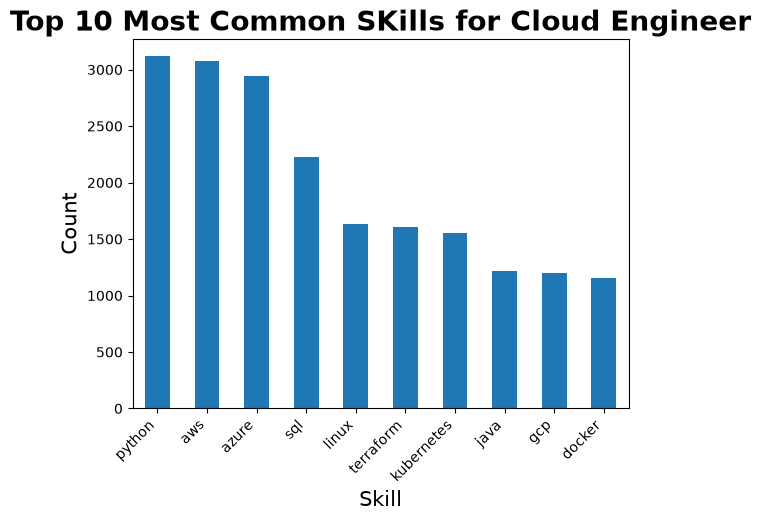

In [18]:
df_CE = df_exploded[df_exploded['job_title_short'] == 'Cloud Engineer'].groupby(['job_skills']).size()
df_CE = df_CE.sort_values(ascending=False)

df_CE.head(10).plot(kind='bar')
plt.title('Top 10 Most Common SKills for Cloud Engineer', fontdict={'fontsize':20, 'fontweight':'bold'})
plt.xlabel('Skill', fontsize = 15)
plt.ylabel('Count', fontsize = 15)
plt.xticks(rotation = 45, ha = 'right')
plt.show()

## 🟨 Average Salary by Skill (2.11.2) - Problem

Explode the job_skills column in the DataFrame and calculate the average salary for each skill. Display the top 5 skills with the highest average salary.

In [ ]:
df_exploded = df.explode('job_skills')
skill_salary_avg = df_exploded.groupby('job_skills')['salary_year_avg'].mean().reset_index()
skill_salary_avg = skill_salary_avg.sort_values(by='salary_year_avg', ascending=False).head()

In [32]:
df_salary_avg = df_exploded.groupby('job_skills')['salary_year_avg'].mean().reset_index().sort_values(ascending=False, by='salary_year_avg')
df_salary_avg.head(5)

,job_skills,salary_year_avg
46,debian,196500.000000
177,ringcentral,182500.000000
114,lua,170500.000000
126,mongo,169526.929749
54,dplyr,160667.210526


## 🟥 Unique Skills Count (2.11.3) - Problem
Calculate the number of unique skills required for each job_title_short.

* Explode the job_skills column

* Group by job_title_short

* Count unique skills per title (i.e., num_unique_skills)

* Rename the result column to num_unique_skills and show the first 5 rows


In [83]:
df_count_skills = df_exploded.groupby('job_title_short')['job_skills'].unique()

df_count_skills = df_count_skills.reset_index().explode('job_skills')

df_count_skills = df_count_skills.value_counts().reset_index(name='num_unique_skills')

df_job_skill_unique = df_count_skills.groupby('job_title_short')['job_skills'].size()

df_job_skill_unique = df_job_skill_unique.reset_index(name = 'num_unique_skills')
df_job_skill_unique.head()

,job_title_short,num_unique_skills
0,Business Analyst,223
1,Cloud Engineer,213
2,Data Analyst,235
3,Data Engineer,239
4,Data Scientist,237


In [87]:
unique_skills_count = df_exploded.groupby('job_title_short')['job_skills'].nunique().reset_index()
unique_skills_count.columns = ['job_title_short', 'num_unique_skills']
unique_skills_count.head()

,job_title_short,num_unique_skills
0,Business Analyst,223
1,Cloud Engineer,213
2,Data Analyst,235
3,Data Engineer,239
4,Data Scientist,237


In [85]:
unique_skills_count = df_exploded.groupby('job_title_short')['job_skills'].transform('nunique')

In [ ]:
# dfj_exploded = dfj.explode('job_skills')
# # number of unique skills
# dfj_exploded['num_unique_skills'] = dfj_exploded.groupby('job_title_short')['job_skills'].transform('nunique')
# print(dfj_exploded[['job_title_short', 'job_skills', 'num_unique_skills']].head(5))